In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from pandas.api.types import CategoricalDtype
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.datasets import make_classification
import scipy.stats as stats
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    make_scorer
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("../data/raw/hospital_readmissions.csv")


# Definir Target com foco (readmitted)

In [3]:
df = pd.read_csv("../data/raw/hospital_readmissions.csv")
y = df['readmitted']

# Definir Features 

In [4]:
X = df.drop('readmitted', axis=1)


In [5]:
X.shape

(25000, 16)

In [6]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                25000 non-null  str  
 1   time_in_hospital   25000 non-null  int64
 2   n_lab_procedures   25000 non-null  int64
 3   n_procedures       25000 non-null  int64
 4   n_medications      25000 non-null  int64
 5   n_outpatient       25000 non-null  int64
 6   n_inpatient        25000 non-null  int64
 7   n_emergency        25000 non-null  int64
 8   medical_specialty  25000 non-null  str  
 9   diag_1             25000 non-null  str  
 10  diag_2             25000 non-null  str  
 11  diag_3             25000 non-null  str  
 12  glucose_test       25000 non-null  str  
 13  A1Ctest            25000 non-null  str  
 14  change             25000 non-null  str  
 15  diabetes_med       25000 non-null  str  
dtypes: int64(7), str(9)
memory usage: 4.3 MB


In [7]:
numerical_features = ['time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency']
categorical_features = ['age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']

# Identificação das variáveis

As variáveis foram separadas em numéricas e categóricas para permitir a aplicação de técnicas de pré-processamento específicas para cada tipo de dado. Variáveis numéricas serão mantidas em sua representação original, enquanto as categóricas serão posteriormente codificadas para utilização pelos algoritmos de Machine Learning.

In [8]:
y.shape

(25000,)

In [9]:
print(sorted(df['age'].unique()))

['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']


In [10]:
df = pd.read_csv("../data/raw/hospital_readmissions.csv")

X = df.drop(columns='readmitted')
y = df['readmitted']

numerical_features = [
    'time_in_hospital',
    'n_lab_procedures',
    'n_procedures',
    'n_medications',
    'n_outpatient',
    'n_inpatient',
    'n_emergency'
]

ordinal_features = [
    'age',
    'glucose_test',
    'A1Ctest',
    'change',
    'diabetes_med'
]

onehot_features = [
    'medical_specialty',
    'diag_1',
    'diag_2',
    'diag_3'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),

        ('ord',
         OrdinalEncoder(categories=[
             ['[40-50)', '[50-60)', '[60-70)',
              '[70-80)', '[80-90)', '[90-100)'],
             ['no', 'normal', 'high'],
             ['no', 'normal', 'high'],
             ['no', 'yes'],
             ['no', 'yes']]),ordinal_features),

        ('cat',
         OneHotEncoder(
             handle_unknown='ignore',
             sparse_output=False),onehot_features)],remainder='drop')



# Identificação das Features
Numerical Features: variáveis quantitativas que serão utilizadas em sua escala original (com possibilidade de padronização posteriormente).
Ordinal Features: variáveis categóricas que apresentam uma ordem natural entre suas categorias.
One-Hot Features: variáveis categóricas nominais, sem relação hierárquica entre seus valores.

## Train-Test Split

Nesta etapa, o dataset é dividido em conjuntos de treino e teste.
O conjunto de treino será utilizado para ajustar o pipeline de pré-processamento e treinar os modelos, enquanto o conjunto de teste permanecerá isolado para avaliar o desempenho em dados nunca vistos.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [12]:
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')


X_train: (20000, 16)
X_test: (5000, 16)
y_train: (20000,)
y_test: (5000,)


In [13]:
print("Distribuição original:")
print(y.value_counts(normalize=True) * 100)

print("\nTreino:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTeste:")
print(y_test.value_counts(normalize=True) * 100)

Distribuição original:
readmitted
no     52.984
yes    47.016
Name: proportion, dtype: float64

Treino:
readmitted
no     52.985
yes    47.015
Name: proportion, dtype: float64

Teste:
readmitted
no     52.98
yes    47.02
Name: proportion, dtype: float64


In [14]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [15]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(20000, 43)
(5000, 43)


In [16]:
feature_names = preprocessor.get_feature_names_out()

print(f'Total de features após o pré-processamento: {len(feature_names)}')


Total de features após o pré-processamento: 43


In [17]:
feature_names[:20]

array(['num__time_in_hospital', 'num__n_lab_procedures',
       'num__n_procedures', 'num__n_medications', 'num__n_outpatient',
       'num__n_inpatient', 'num__n_emergency', 'ord__age',
       'ord__glucose_test', 'ord__A1Ctest', 'ord__change',
       'ord__diabetes_med', 'cat__medical_specialty_Cardiology',
       'cat__medical_specialty_Emergency/Trauma',
       'cat__medical_specialty_Family/GeneralPractice',
       'cat__medical_specialty_InternalMedicine',
       'cat__medical_specialty_Missing', 'cat__medical_specialty_Other',
       'cat__medical_specialty_Surgery', 'cat__diag_1_Circulatory'],
      dtype=object)

## Modelo Base - Regressão Logistica

In [18]:
modelo = LogisticRegression(
    random_state=42,
    max_iter=1000
)
modelo.fit(X_train_processed, y_train)

y_pred = modelo.predict(X_test_processed)

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, pos_label="yes"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred, pos_label="yes"):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred, pos_label="yes"):.4f}')

Accuracy : 0.6104
Precision: 0.6297
Recall   : 0.4160
F1 Score : 0.5010


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.60      0.78      0.68      2649
         yes       0.63      0.42      0.50      2351

    accuracy                           0.61      5000
   macro avg       0.62      0.60      0.59      5000
weighted avg       0.61      0.61      0.60      5000



In [20]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['no', 'yes']
)

print(cm)

[[2074  575]
 [1373  978]]


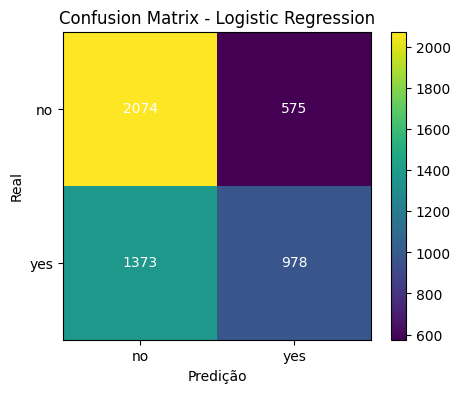

In [21]:


plt.figure(figsize=(5,4))
plt.imshow(cm)

plt.xticks([0,1], ['no','yes'])
plt.yticks([0,1], ['no','yes'])

plt.xlabel('Predição')
plt.ylabel('Real')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 color='white')

plt.title('Confusion Matrix - Logistic Regression')
plt.colorbar()

plt.show()

### Resultados do Modelo Baseline

A Regressão Logística foi utilizada como primeiro modelo de classificação para estabelecer uma referência de desempenho.

As métricas obtidas servirão como base de comparação para modelos mais sofisticados, permitindo avaliar se algoritmos mais complexos realmente agregam ganho preditivo ao problema de readmissão hospitalar.

### Análise do modelo baseline

A Regressão Logística apresentou acurácia de aproximadamente 61%, superando a previsão baseada apenas na classe majoritária. O modelo obteve boa precisão na identificação de pacientes readmitidos, porém apresentou recall relativamente baixo, indicando dificuldade em identificar todos os casos positivos. Esses resultados servirão como referência para comparação com modelos mais complexos, capazes de capturar relações não lineares entre as variáveis.

In [22]:
X_train_processed.shape

(20000, 43)

In [23]:
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train_processed, y_train)

y_pred = modelo.predict(X_test_processed)

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, pos_label="yes"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred, pos_label="yes"):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred, pos_label="yes"):.4f}')

print(classification_report(y_test, y_pred))

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['no', 'yes']
)

print(cm)

Accuracy : 0.6074
Precision: 0.5974
Recall   : 0.5062
F1 Score : 0.5480
              precision    recall  f1-score   support

          no       0.61      0.70      0.65      2649
         yes       0.60      0.51      0.55      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.60      5000
weighted avg       0.61      0.61      0.60      5000

[[1847  802]
 [1161 1190]]


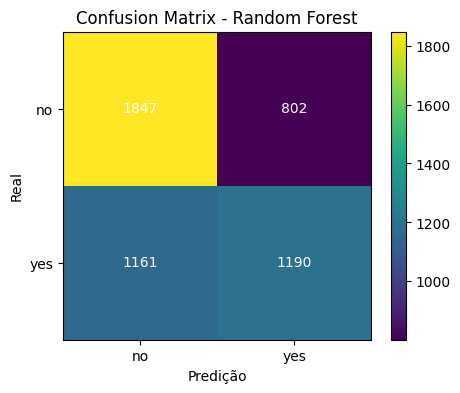

In [24]:
plt.figure(figsize=(5,4))
plt.imshow(cm)

plt.xticks([0,1], ['no','yes'])
plt.yticks([0,1], ['no','yes'])

plt.xlabel('Predição')
plt.ylabel('Real')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 color='white')

plt.title('Confusion Matrix - Random Forest')
plt.colorbar()

plt.show()

# Análise 
O modelo Random Forest apresentou desempenho semelhante ao da Regressão Logística em termos de acurácia geral (60,7% vs 61,0%). Entretanto, obteve melhora significativa no Recall (50,6% contra 41,6%) e no F1-Score (0,548 contra 0,501), indicando maior capacidade de identificar pacientes com risco de readmissão. Apesar do aumento no número de falsos positivos, a redução dos falsos negativos torna o modelo potencialmente mais adequado para aplicações em contexto hospitalar, onde deixar de identificar um paciente de alto risco pode gerar impactos clínicos relevantes.

In [25]:
importancias = modelo.feature_importances_

df_importancias = pd.DataFrame({
    'feature': feature_names,
    'importance': importancias
})

df_importancias.sort_values(
    by='importance',
    ascending=False
).head(10)

,feature,importance
1,num__n_lab_procedures,0.148125
3,num__n_medications,0.130063
0,num__time_in_hospital,0.093194
7,ord__age,0.070535
2,num__n_procedures,0.057518
5,num__n_inpatient,0.055894
4,num__n_outpatient,0.027502
10,ord__change,0.022039
9,ord__A1Ctest,0.021824
41,cat__diag_3_Other,0.020766


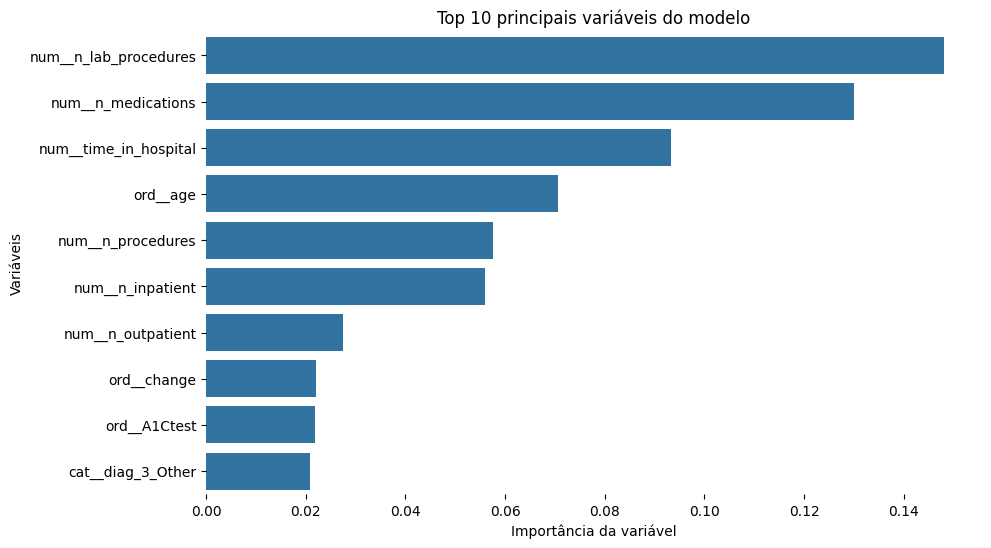

In [26]:
top10 = df_importancias.sort_values(by='importance', ascending=False).head(10)


plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top10, x='importance', y='feature')

plt.title('Top 10 principais variáveis do modelo')
plt.xlabel('Importância da variável')
plt.ylabel('Variáveis')

sns.despine(left=True, bottom=True)

plt.show()

# Análise de importância das variáveis
A análise das importâncias das variáveis mostrou que fatores relacionados à complexidade clínica do paciente, como número de procedimentos laboratoriais, quantidade de medicamentos prescritos e tempo presente no hospital, foram os principais preditores de readmissão hospitalar. Além disso, variáveis associadas ao histórico de utilização do sistema de saúde, como internações e atendimentos ambulatoriais prévios, também apresentaram relevância significativa. Esses resultados corroboram os achados da análise exploratória realizada anteriormente.

# Observação
Como o objetivo é identificar pacientes com maior risco de readmissão, optou-se por utilizar F1-Score como principal métrica de otimização, pois ela equilibra Precision e Recall.

In [27]:
modelo = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators' : stats.randint(50, 500),
    'max_depth' : stats.randint(5, 30),
    'min_samples_split' : stats.randint(2, 20),
    'min_samples_leaf' : stats.randint(1, 10),
    'bootstrap' : [True, False]
}


f1_yes = make_scorer(
    f1_score,
    pos_label='yes'
)

random_search = RandomizedSearchCV(
    estimator=modelo,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring=f1_yes,
    random_state=42,
    n_jobs=-1,
    error_score='raise'
)

random_search.fit(X_train_processed, y_train)

print("Melhores hiperparametros:", random_search.best_params_)
print("Melhor Acurária:", random_search.best_score_)

Melhores hiperparametros: {'bootstrap': True, 'max_depth': 28, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 329}
Melhor Acurária: 0.5593126553080392


In [28]:
y_train.unique()

<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

In [29]:
random_search.cv_results_['mean_test_score']

array([0.55341989, 0.55273587, 0.53505268, 0.53824942, 0.55181961,
       0.54288422, 0.55854308, 0.55040721, 0.55824621, 0.52968111,
       0.54672627, 0.55584309, 0.53384097, 0.55691066, 0.55355786,
       0.55514588, 0.55428579, 0.55014003, 0.52954397, 0.53610296,
       0.54856198, 0.54029129, 0.55353072, 0.54270733, 0.53487488,
       0.5552457 , 0.54443016, 0.53660911, 0.54905195, 0.55399952,
       0.55458191, 0.54988192, 0.55585348, 0.52446022, 0.53636186,
       0.5361825 , 0.55465641, 0.5534358 , 0.53798586, 0.55242319,
       0.55842193, 0.52759635, 0.53816343, 0.55931266, 0.55547187,
       0.55313465, 0.53537002, 0.53514939, 0.52736643, 0.52883449])

In [30]:
melhor_modelo = random_search.best_estimator_

In [31]:
y_pred = melhor_modelo.predict(X_test_processed)
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, pos_label="yes"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred, pos_label="yes"):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred, pos_label="yes"):.4f}')

print(classification_report(y_test, y_pred))

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['no', 'yes']
)

print(cm)

Accuracy : 0.6150
Precision: 0.6074
Recall   : 0.5125
F1 Score : 0.5559
              precision    recall  f1-score   support

          no       0.62      0.71      0.66      2649
         yes       0.61      0.51      0.56      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.61      0.61      0.61      5000

[[1870  779]
 [1146 1205]]


In [32]:
resultado_lr = {
    'Modelo' : 'Regressão Logística',
    'Accuracy' : '0.6104',
    'Precision' : '0.6297',
    'Recall' : '0.4160',
    'F1 Score' : '0.5010'
}


resultado_rf = {
    'Modelo' : 'Random Forest',
    'Accuracy' : '0.6074',
    'Precision' : '0.5974',
    'Recall' : '0.5062',
    'F1 Score' : '0.5480'
}

resultado_rf_tunado = {
    'Modelo' : 'Random Forest Tunado',
    'Accuracy' : '0.6150',
    'Precision' : '0.6074',
    'Recall' : '0.5125',
    'F1 Score' : '0.5559'
}

resultados = [
    resultado_lr,
    resultado_rf,
    resultado_rf_tunado
]

tabela_modelos = pd.DataFrame(resultados)


tabela_modelos = tabela_modelos.sort_values(
    by='F1 Score',
    ascending=False
)

tabela_modelos


,Modelo,Accuracy,Precision,Recall,F1 Score
2,Random Forest Tunado,0.6150,0.6074,0.5125,0.5559
1,Random Forest,0.6074,0.5974,0.5062,0.5480
0,Regressão Logística,0.6104,0.6297,0.4160,0.5010


In [33]:
tabela_modelos['Accuracy'] = tabela_modelos['Accuracy'].astype(float)
tabela_modelos['Precision'] = tabela_modelos['Precision'].astype(float)
tabela_modelos['Recall'] = tabela_modelos['Recall'].astype(float)
tabela_modelos['F1 Score'] = tabela_modelos['F1 Score'].astype(float)

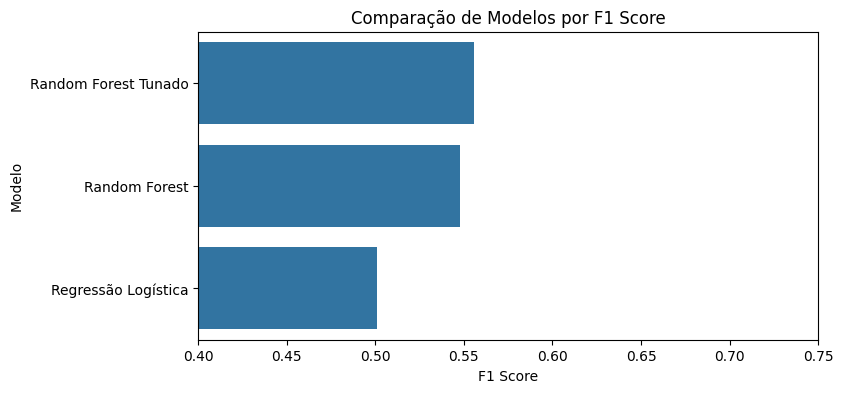

In [34]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=tabela_modelos,
    x='F1 Score',
    y='Modelo'
)

plt.xlim(0.40, 0.75)

plt.title('Comparação de Modelos por F1 Score')
plt.xlabel('F1 Score')
plt.ylabel('Modelo')

plt.show()

# Conclusão Técnica
O objetivo deste projeto foi desenvolver um modelo capaz de prever a readmissão hospitalar de pacientes a partir de informações clínicas e administrativas coletadas durante a internação.

Inicialmente foi realizada uma Análise Exploratória dos Dados (EDA) para entender o comportamento das variáveis e identificar possíveis padrões relacionados à readmissão. Em seguida, os dados passaram pelas etapas de pré-processamento, incluindo padronização de variáveis numéricas e codificação de variáveis categóricas.

Como modelo baseline foi utilizada a Regressão Logística. Posteriormente, foi implementado o algoritmo Random Forest e realizada a otimização de hiperparâmetros utilizando RandomizedSearchCV.

O melhor desempenho foi obtido pelo modelo Random Forest Tunado, que alcançou:

Accuracy: 61,50%
Precision: 60,74%
Recall: 51,25%
F1 Score: 55,59%

A análise de importância das variáveis mostrou que o número de procedimentos laboratoriais realizados, a quantidade de medicamentos prescritos e o tempo de internação foram os fatores com maior impacto nas previsões do modelo. A idade também apresentou relevância, porém com menor influência quando comparada aos fatores relacionados à complexidade do atendimento.

Os resultados demonstram a aplicação prática de um fluxo completo de Data Science, envolvendo análise exploratória, pré-processamento, modelagem, otimização de hiperparâmetros e interpretação dos resultados.

# Conclusão de Negócio

A análise mostrou que pacientes que passaram por um maior número de procedimentos laboratoriais, utilizaram mais medicamentos e permaneceram mais tempo dentro de hospitais apresentaram maior probabilidade de readmissão hospitalar.

Esses fatores podem ser utilizados como indicadores de atenção para identificar pacientes que possivelmente necessitam de um acompanhamento mais próximo após a alta médica.

Embora o modelo não tenha como objetivo substituir a avaliação clínica, ele pode atuar como uma ferramenta de apoio para equipes médicas e gestores hospitalares, auxiliando na identificação antecipada de pacientes com maior risco de retorno ao hospital.

Na prática, soluções desse tipo podem contribuir para uma melhor gestão de recursos, redução de custos associados a readmissões e melhoria do acompanhamento dos pacientes após a internação.


# Fim

#


#

#


# Salvar o melhor modelo


In [35]:
pipeline = Pipeline([
    ('preprocessador', preprocessor),
    ('model', melhor_modelo)
])


In [36]:
joblib.dump(pipeline, '../models/hospital_readmission_pipeline.pkl')

['../models/hospital_readmission_pipeline.pkl']

In [37]:
modelo_carregado = joblib.load(
    '../models/hospital_readmission_pipeline.pkl'
)

In [38]:
previsoes = modelo_carregado.predict(X_test.head())

print(previsoes)

['yes' 'no' 'no' 'no' 'no']
